# The Kingdom of Kilowattia & the City of Watt-a-Lot
### An illustrated walkthrough of the coupled national/city energy model

This notebook doesn't add any new modelling logic — every number and every
solve here calls straight into `national/model.py`, `city/model.py`,
`coupling/loop.py`, and `common/scenario.py`. What it adds is pictures, and
a narrated path through them, for anyone who'd rather look at a chart than
reconstruct one from `parameters.yaml` in their head.

Run it top to bottom (`pixi run notebook`, or open it directly). Each
section below matches one piece of the README's "What's in the box".


In [1]:
import sys, os
from pathlib import Path

# Jupyter sometimes starts the kernel in notebooks/, sometimes in the repo
# root, depending on how it's launched. Make sure we're at the repo root
# either way, so `from national.model import ...` etc. resolve.
_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "parameters.yaml").exists() else _cwd.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from common.scenario import build_scenario
from national.model import solve_national
from city.model import solve_city, heat_pump_cop, heat_pump_share
from coupling.loop import run_coupling, initial_demand_guess

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

SEASON_NAMES = ["Winter", "Spring", "Summer", "Autumn"]
SEASON_COLORS = {0: "#4C72B0", 1: "#55A868", 2: "#C44E52", 3: "#DD8452"}

scenario = build_scenario()
national_data = scenario["national_data"]
city_data = scenario["city_data"]
rest_of_country_demand = scenario["rest_of_country_demand"]
weather = scenario["weather"]
days, hours = scenario["days"], scenario["hours"]

def to_grid(d):
    # dict keyed by (day, hour) -> a (4, 24) array, one row per season
    return np.array([[d[(day, h)] for h in hours] for day in days])

print(f"City floor area:              {city_data.total_floor_area_m2:>14,.0f} m2")
print(f"Rest-of-country peak demand:  {max(rest_of_country_demand.values()):>14,.0f} MW")
print(f"City share of national peak:  {scenario['params']['city']['target_share_of_national_peak']:>14.0%}")


City floor area:                 237,688,651 m2
Rest-of-country peak demand:          42,927 MW
City share of national peak:             20%


## Act I — the weather

Kilowattia and Watt-a-Lot don't get independent weather. They get the
*same* weather, generated once in `common/weather.py` and handed to both
models. That's the whole trick behind the story this project tells: a
cold evening has to be a cold evening — and a low-wind evening — in both
places at once, or there's no reason winter evenings should be expensive
at all.

The anti-correlation isn't hand-tuned as a correlation coefficient
between two independent series. Instead, one shared "synoptic regime"
value drives both temperature and wind: when it's negative, it's cold
*and* still — a classic winter high-pressure blocking pattern.


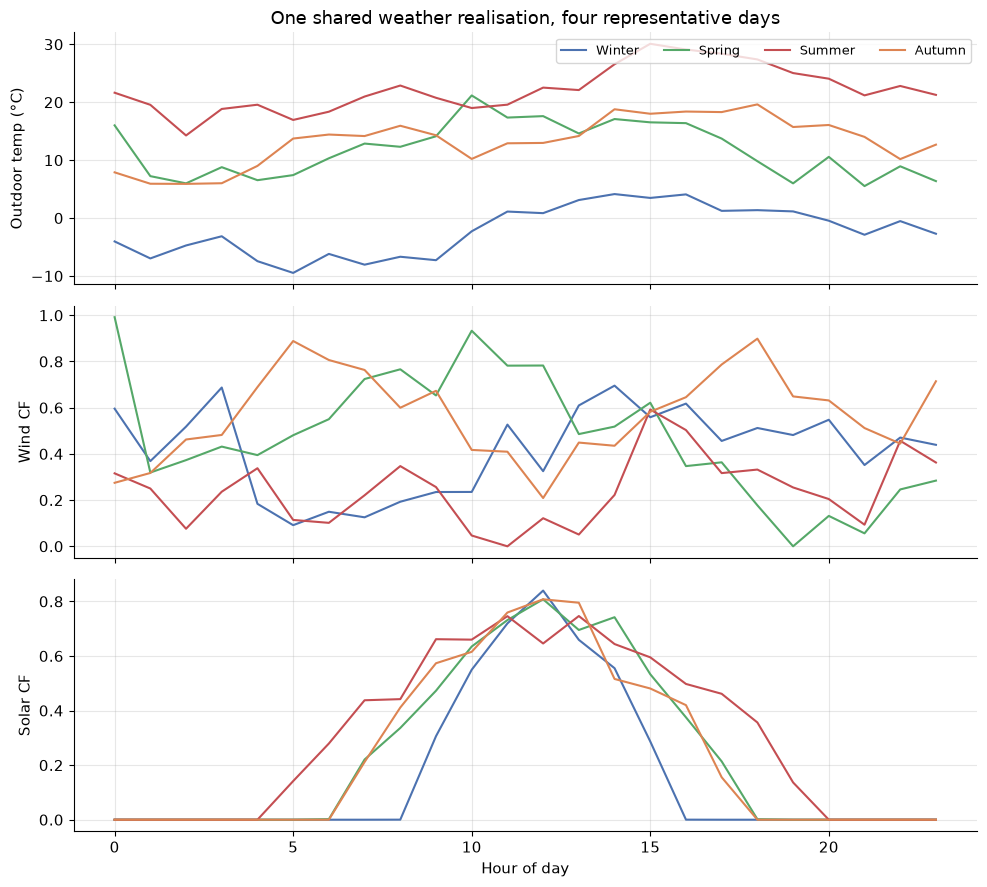

In [2]:
temp_grid = to_grid(weather["temperature_C"])
wind_grid = to_grid(weather["wind_cf"])
solar_grid = to_grid(weather["solar_cf"])

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for i, season in enumerate(SEASON_NAMES):
    axes[0].plot(hours, temp_grid[i], label=season, color=SEASON_COLORS[i])
    axes[1].plot(hours, wind_grid[i], color=SEASON_COLORS[i])
    axes[2].plot(hours, solar_grid[i], color=SEASON_COLORS[i])

axes[0].set_ylabel("Outdoor temp (°C)")
axes[0].set_title("One shared weather realisation, four representative days")
axes[0].legend(loc="upper right", ncol=4, fontsize=9)
axes[1].set_ylabel("Wind CF")
axes[2].set_ylabel("Solar CF")
axes[2].set_xlabel("Hour of day")
plt.tight_layout()
plt.show()


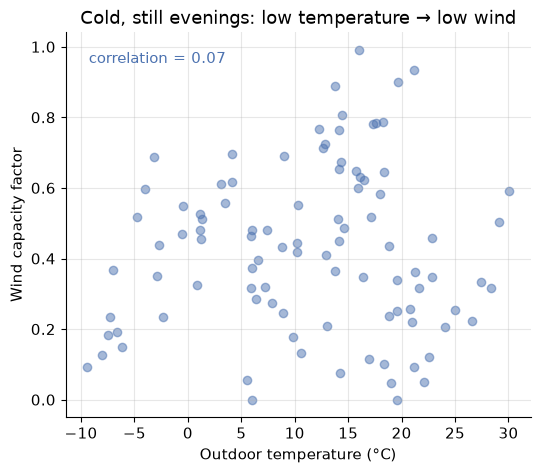

In [3]:
temps_flat = np.array(list(weather["temperature_C"].values()))
wind_flat = np.array([weather["wind_cf"][k] for k in weather["temperature_C"]])
corr = np.corrcoef(temps_flat, wind_flat)[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(temps_flat, wind_flat, alpha=0.5, color="#4C72B0")
ax.set_xlabel("Outdoor temperature (°C)")
ax.set_ylabel("Wind capacity factor")
ax.set_title("Cold, still evenings: low temperature → low wind")
ax.annotate(f"correlation = {corr:.2f}", xy=(0.05, 0.92), xycoords="axes fraction",
            fontsize=11, color="#4C72B0")
plt.show()


## Act II — Kilowattia solves its own problem

Model 1 is a linear program (Pyomo + HiGHS): minimise annualised capital
cost plus fuel/operating cost, subject to supply = demand every hour,
renewables capped by capacity × availability, battery state-of-charge
accounting, and an annual CO₂ cap. Solved here on its own, fed only the
"rest of country" demand — i.e. pretending Watt-a-Lot doesn't exist yet.


In [4]:
result_national_only = solve_national(national_data)

print("Built capacity (MW):")
for tech, cap in result_national_only["capacity"].items():
    print(f"  {tech:8s} {cap:12,.0f}")


Built capacity (MW):
  gas            31,402
  wind           49,277
  solar               0
  battery         5,938


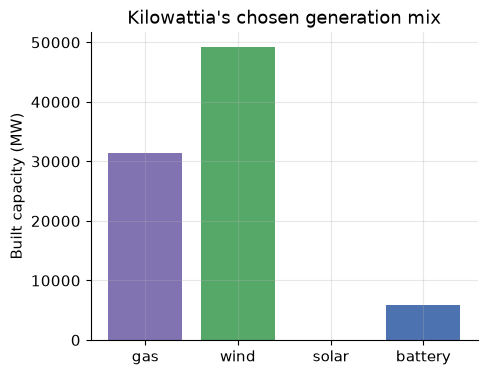

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
techs = list(result_national_only["capacity"].keys())
caps = [result_national_only["capacity"][t] for t in techs]
colors = ["#8172B2", "#55A868", "#C44E52", "#4C72B0"]
ax.bar(techs, caps, color=colors[:len(techs)])
ax.set_ylabel("Built capacity (MW)")
ax.set_title("Kilowattia's chosen generation mix")
plt.show()


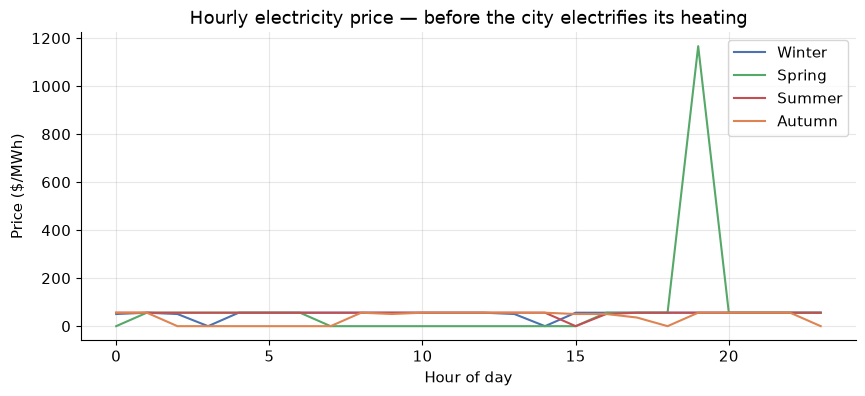

In [6]:
price_grid = to_grid(result_national_only["price"])

fig, ax = plt.subplots()
for i, season in enumerate(SEASON_NAMES):
    ax.plot(hours, price_grid[i], label=season, color=SEASON_COLORS[i])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Price ($/MWh)")
ax.set_title("Hourly electricity price — before the city electrifies its heating")
ax.legend()
plt.show()


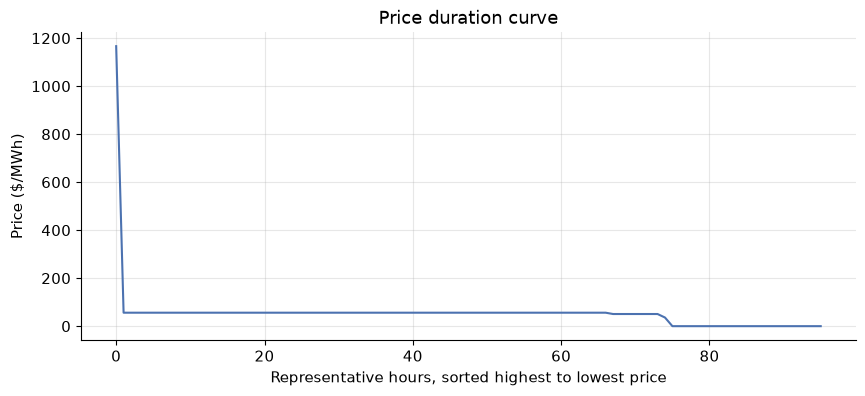

min=-0.0  median=56.1  mean=54.8  max=1166.5  $/MWh


In [7]:
prices_flat = np.array(list(result_national_only["price"].values()))

fig, ax = plt.subplots()
ax.plot(np.sort(prices_flat)[::-1], color="#4C72B0")
ax.set_xlabel("Representative hours, sorted highest to lowest price")
ax.set_ylabel("Price ($/MWh)")
ax.set_title("Price duration curve")
plt.show()

print(f"min={prices_flat.min():.1f}  median={np.median(prices_flat):.1f}  "
      f"mean={prices_flat.mean():.1f}  max={prices_flat.max():.1f}  $/MWh")


A quick reality check worth keeping in mind whenever you retune
`parameters.yaml`: the median price here should land somewhere near gas's
variable cost plus whatever the CO₂ cap's shadow price adds on top —
tens of $/MWh, not thousands. If it isn't, something's binding harder
than intended (see the README's "Dispatches from the loop" for the two
ways this went wrong during development, and how they were fixed).


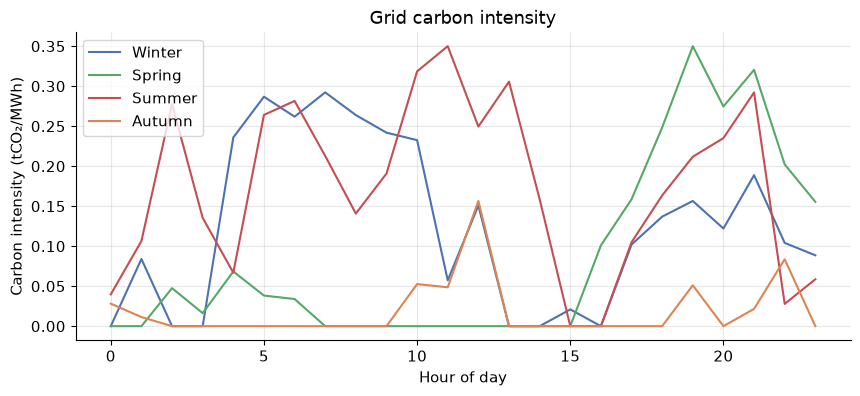

In [8]:
carbon_grid = to_grid(result_national_only["carbon_intensity"])

fig, ax = plt.subplots()
for i, season in enumerate(SEASON_NAMES):
    ax.plot(hours, carbon_grid[i], label=season, color=SEASON_COLORS[i])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Carbon intensity (tCO₂/MWh)")
ax.set_title("Grid carbon intensity")
ax.legend()
plt.show()


## Act III — Watt-a-Lot decides how to heat itself

Model 2 isn't an optimiser. Each of four building archetypes weighs a
heat pump against a gas boiler, hour by hour, based on the price Kilowattia
just handed over and the outdoor temperature (which sets both the heat
pump's COP and how much heat is even needed). The choice is a logistic
curve, not a light switch — see the brief for why a hard switch would make
the whole city flip at once and give damping nothing to tame.


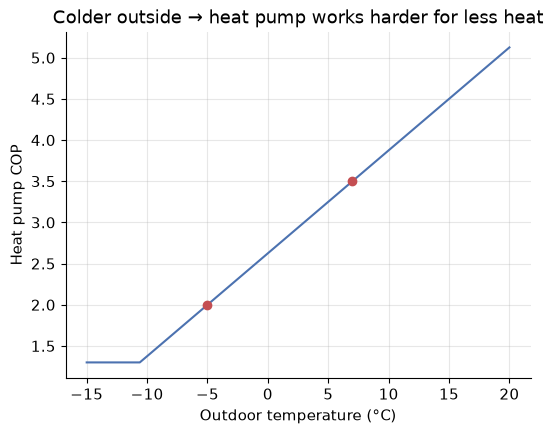

In [9]:
temps_range = np.linspace(-15, 20, 200)
cops = [heat_pump_cop(t, city_data) for t in temps_range]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(temps_range, cops, color="#4C72B0")
for anchor_temp, anchor_cop in [city_data.cop_anchor_low, city_data.cop_anchor_high]:
    ax.scatter([anchor_temp], [anchor_cop], color="#C44E52", zorder=5)
ax.set_xlabel("Outdoor temperature (°C)")
ax.set_ylabel("Heat pump COP")
ax.set_title("Colder outside → heat pump works harder for less heat")
plt.show()


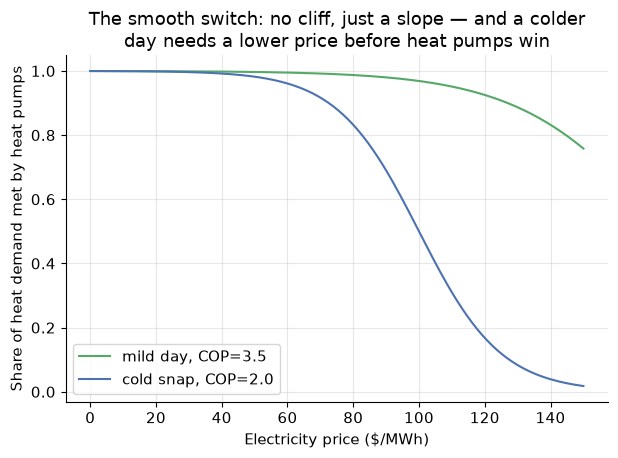

In [10]:
price_range = np.linspace(0, 150, 200)
cost_gas_per_MWh_heat = city_data.gas_price_per_MWh_fuel / city_data.boiler_efficiency

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, cop, color in [("mild day, COP=3.5", 3.5, "#55A868"),
                           ("cold snap, COP=2.0", 2.0, "#4C72B0")]:
    shares = [heat_pump_share(p / cop, cost_gas_per_MWh_heat, city_data.share_steepness)
              for p in price_range]
    ax.plot(price_range, shares, label=label, color=color)

ax.set_xlabel("Electricity price ($/MWh)")
ax.set_ylabel("Share of heat demand met by heat pumps")
ax.set_title("The smooth switch: no cliff, just a slope — and a colder\nday needs a lower price before heat pumps win")
ax.legend()
plt.show()


## Act IV — the loop

This is the entire contribution, twelve lines long: solve the country,
read off its prices, run the city's response, damp the update, repeat.
Log every iteration, because the trajectory is the result — not just
wherever it lands.


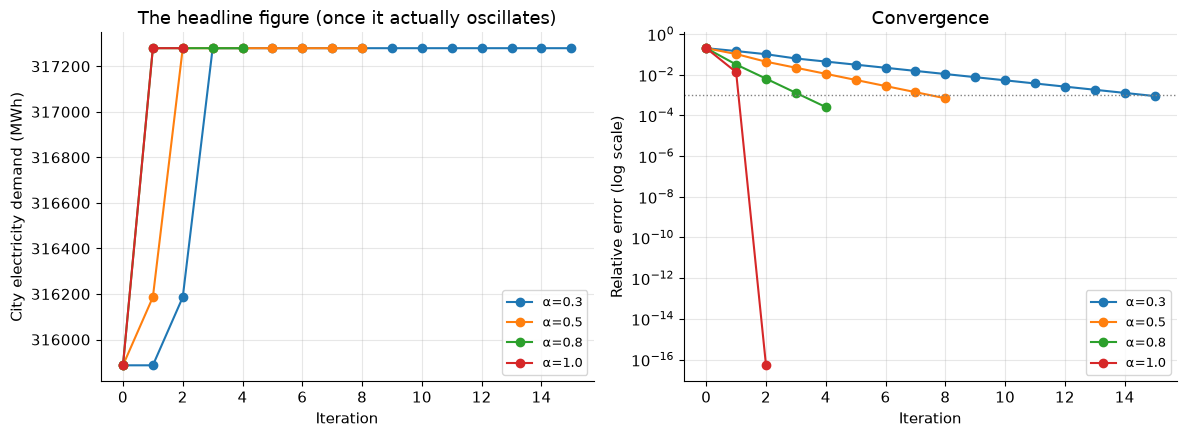

In [11]:
alphas_to_show = [0.3, 0.5, 0.8, 1.0]
histories = {}
for a in alphas_to_show:
    h, _ = run_coupling(national_data, city_data, rest_of_country_demand,
                         alpha=a, max_iter=25, verbose=False)
    histories[a] = h

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for a, h in histories.items():
    iters = [r["iteration"] for r in h]
    axes[0].plot(iters, [r["city_total_demand_MWh"] for r in h], marker="o", label=f"α={a}")
    axes[1].semilogy(iters, [r["error"] for r in h], marker="o", label=f"α={a}")

axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("City electricity demand (MWh)")
axes[0].set_title("The headline figure (once it actually oscillates)")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Relative error (log scale)")
axes[1].axhline(1e-3, linestyle=":", color="gray", linewidth=1)
axes[1].set_title("Convergence")
for ax in axes:
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Honest caveat, as of this commit:** every α above converges in well
under 10 iterations, including α=1.0 (no damping at all). That's not a
bug — it means the coupling, as currently calibrated, is more stable than
the brief's headline result needs it to be. The likeliest reason is the
battery: it's built to smooth exactly the price volatility Watt-a-Lot is
supposed to overreact to. See the README's "Dispatches from the loop" for
the knobs worth turning (city size, CO₂ cap tightness, battery
economics, logistic steepness) to bring the oscillation back. This chart
is the scaffold that result will slot into once it does.


## The substantive point — what ignoring feedback costs you

The brief's real claim isn't about oscillation for its own sake — it's
that **modelling a city in isolation gives you an answer that's wrong in
a specific, predictable direction**. The way to check that here is to
compare converged national prices under two assumptions about the city's
demand:

- **"ignoring feedback"**: the city's demand is fixed at a single
  price-blind guess (its response to one flat, average price, held fixed
  regardless of what the national model actually does with it) — a stand-in
  for a planner who forecasts city electrification once and never revisits it.
- **"with feedback"**: the fully converged loop, where the city keeps
  re-deciding its heat pump/boiler split against whatever price the
  country actually produces.

If the coupling matters, these should differ — and differ *more* on cold,
low-wind evenings specifically, since that's where the shared weather
realisation makes the national price most sensitive to how much of the
city's heat demand shows up as electricity.


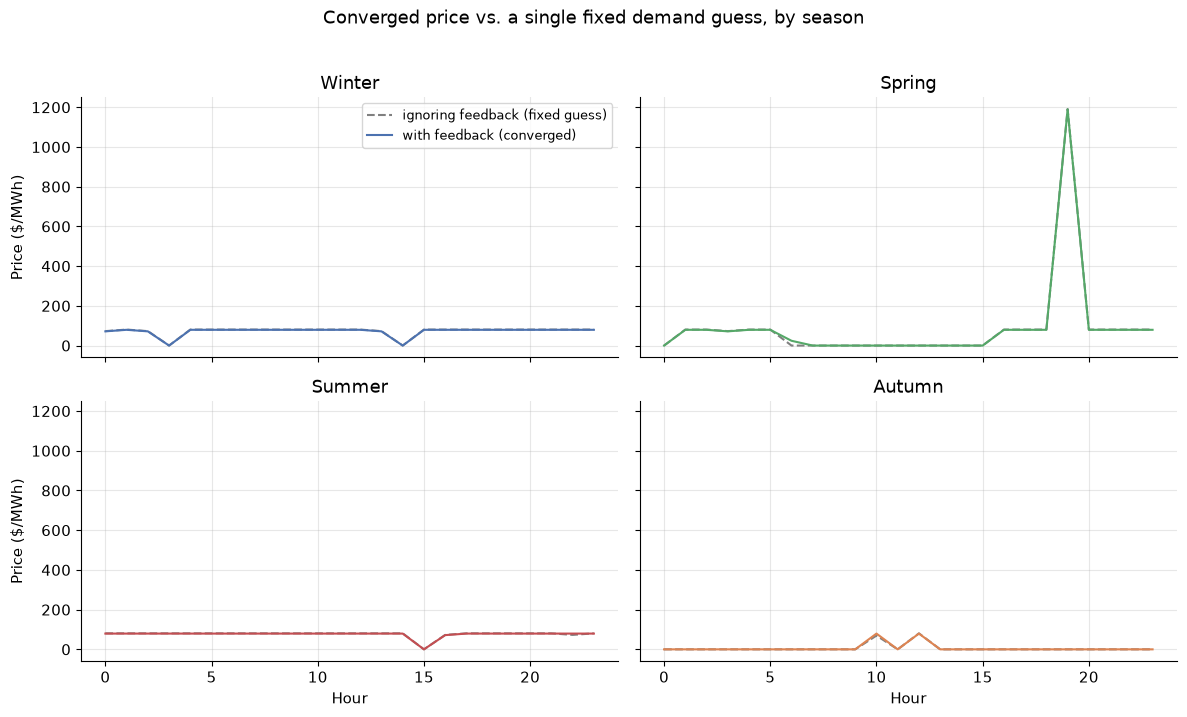

Winter evening (18:00-22:00) average price:
  ignoring feedback: $80.6/MWh
  with feedback:     $79.3/MWh
  difference:        $-1.2/MWh (-1.5%)


In [12]:
naive_city_demand = initial_demand_guess(city_data)
national_data.demand = {k: rest_of_country_demand[k] + naive_city_demand[k]
                         for k in naive_city_demand}
result_naive = solve_national(national_data)

_, final = run_coupling(national_data, city_data, rest_of_country_demand,
                         alpha=0.5, verbose=False)
result_coupled = final["national_result"]

price_naive_grid = to_grid(result_naive["price"])
price_coupled_grid = to_grid(result_coupled["price"])

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for i, season in enumerate(SEASON_NAMES):
    ax = axes.flat[i]
    ax.plot(hours, price_naive_grid[i], "--", color="gray", label="ignoring feedback (fixed guess)")
    ax.plot(hours, price_coupled_grid[i], color=SEASON_COLORS[i], label="with feedback (converged)")
    ax.set_title(season)
    if i >= 2:
        ax.set_xlabel("Hour")
    if i % 2 == 0:
        ax.set_ylabel("Price ($/MWh)")

axes.flat[0].legend(fontsize=9)
fig.suptitle("Converged price vs. a single fixed demand guess, by season", y=1.02)
plt.tight_layout()
plt.show()

winter_evening_naive = price_naive_grid[0, 18:22].mean()
winter_evening_coupled = price_coupled_grid[0, 18:22].mean()
print(f"Winter evening (18:00-22:00) average price:")
print(f"  ignoring feedback: ${winter_evening_naive:,.1f}/MWh")
print(f"  with feedback:     ${winter_evening_coupled:,.1f}/MWh")
print(f"  difference:        ${winter_evening_coupled - winter_evening_naive:+,.1f}/MWh "
      f"({(winter_evening_coupled/winter_evening_naive - 1):+.1%})")


**Reading this honestly:** as calibrated right now, the two numbers
above are close — a few percent apart, and not reliably in one direction
across seasons. That's the same underlying story as Act IV's caveat, not
a separate problem: the initial guess `initial_demand_guess()` feeds the
loop is already close to the converged answer, because the city's price
response isn't yet sharp or large enough to move far from a flat-price
starting point. The mechanism this cell is built to demonstrate — that a
one-shot, price-blind city forecast diverges from what the city actually
does once it can react — is real and is exactly what
`common/scenario.py` and `coupling/loop.py` compute. It just needs the
same tuning as Act IV (city size, CO₂ cap, battery economics, logistic
steepness) before the gap here is large enough to be worth a headline.
Re-run this cell after that tuning; the plot and the printed numbers
will tell you immediately whether it's worked.


## Where things stand

- The country and city models both run and solve cleanly, individually
  and coupled.
- Prices are in a believable range (tens of $/MWh, occasional spikes)
  after fixing two real bugs along the way — a representative-day
  weighting mismatch in the duals, and unbounded scarcity pricing from a
  razor-thin capacity margin. Both are written up in the README.
- The city is deliberately sized at ~15–25% of national peak demand, so
  its electrification decisions are not a rounding error to Kilowattia.
- What's still open, and it's one thing wearing two hats: the coupling is
  currently too gentle. That's why Act IV doesn't oscillate even at
  α=1.0, and it's why the "ignoring feedback" comparison above doesn't
  yet show a convincing gap. Turning the same knobs (city size, CO₂ cap,
  battery economics, logistic steepness) should move both results at
  once.

Everything above is reproducible with `pixi run notebook`, and every
number that fed into it lives in [`parameters.yaml`](../parameters.yaml).
